<a href="https://colab.research.google.com/github/tvpian/Diffusion_Models/blob/main/SSD_Gen_AI_1_0_Diffusion_Model_Forward_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_swiss_roll

In [ ]:
print(make_swiss_roll.__doc__)

Generate a swiss roll dataset.

    Read more in the :ref:`User Guide <sample_generators>`.

    Parameters
    ----------
    n_samples : int, default=100
        The number of sample points on the Swiss Roll.

    noise : float, default=0.0
        The standard deviation of the gaussian noise.

    random_state : int, RandomState instance or None, default=None
        Determines random number generation for dataset creation. Pass an int
        for reproducible output across multiple function calls.
        See :term:`Glossary <random_state>`.

    hole : bool, default=False
        If True generates the swiss roll with hole dataset.

    Returns
    -------
    X : ndarray of shape (n_samples, 3)
        The points.

    t : ndarray of shape (n_samples,)
        The univariate position of the sample according to the main dimension
        of the points in the manifold.

    Notes
    -----
    The algorithm is from Marsland [1].

    References
    ----------
    .. [1] S. Marsland,

In [ ]:
n_samples = 1000
data, _ = make_swiss_roll(1000)

In [ ]:
data.shape

(1000, 3)

In [ ]:
data = data[:,[2,0]]/10

In [ ]:
data = data * np.array([1,-2])

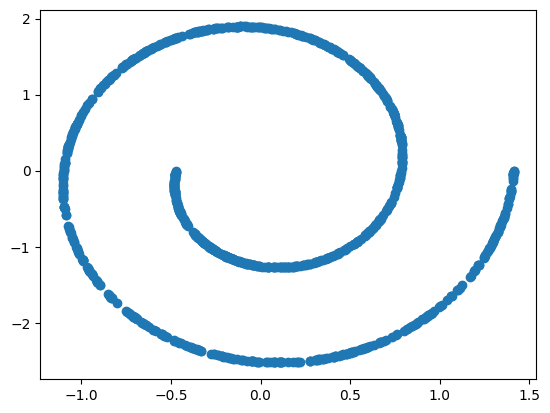

In [ ]:
plt.scatter(data[:,0:1],data[:,1:])

# Forward Process

In [ ]:
def forward_process(data, T, betas):
  for t in range(T):
     beta_t = betas[t]
     mu = data * torch.sqrt(1 -  beta_t)
     std = torch.sqrt(beta_t)
     data =  mu + torch.randn_like(data) * std

  return data


In [ ]:
T = 40
betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1 - 1e-5) + 1e-5
xT = forward_process(torch.from_numpy(data), T, betas)

In [ ]:
print(xT.mean(0))
print(xT.std(0))

tensor([ 0.0084, -0.0089], dtype=torch.float64)
tensor([1.0078, 0.9908], dtype=torch.float64)


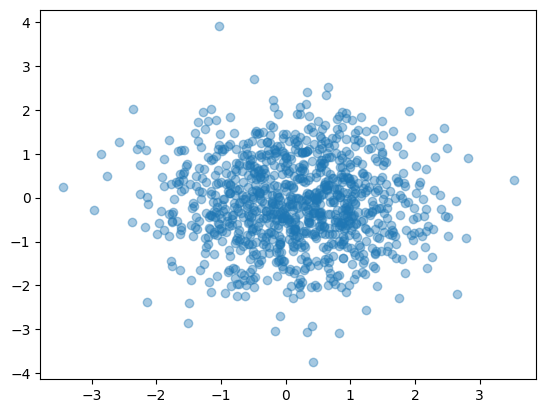

In [ ]:
plt.scatter(xT[:,0].data.numpy(), xT[:,1].data.numpy(), alpha = 0.4)
# plt.xlim([-2, 2])
# plt.ylim([-2, 2])
plt.show()



```
# This is formatted as code
```

# Implement Forward Process without Control Flows

In [ ]:
class DiffusionModel():

  def __init__(self, T):
    self.betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1 - 1e-5) + 1e-5
    self.alphas = 1 - self.betas
    self.alpha_bar = torch.cumprod(self.alphas, dim = 0)

  def sample_batch(self, batch_size, device = 'cpu'):
    data, _ = make_swiss_roll(batch_size)
    data = data[:,[2,0]]/10
    data = data * np.array([1,-1])
    return torch.from_numpy(data).to(device)

  def forward_process(self, x0, t):
    """
    :param t: Number of diffusion steps
    """
    assert t > 0 and t <= T, 't > 0 and t <= T'
    t = t - 1
    mu = x0 * torch.sqrt(self.alpha_bar[t])
    std = torch.sqrt(1 - self.alpha_bar[t])
    epsilon = torch.randn_like(x0)
    data = mu + std * epsilon
    return data


In [ ]:
T = 40
t = 22
batch_size = 1000
model = DiffusionModel(T)
data = model.sample_batch(batch_size)
xT = model.forward_process(data, t)

In [ ]:
print(xT.mean(0))
print(xT.std(0))

tensor([ 0.0124, -0.2272], dtype=torch.float64)
tensor([0.6900, 0.6714], dtype=torch.float64)


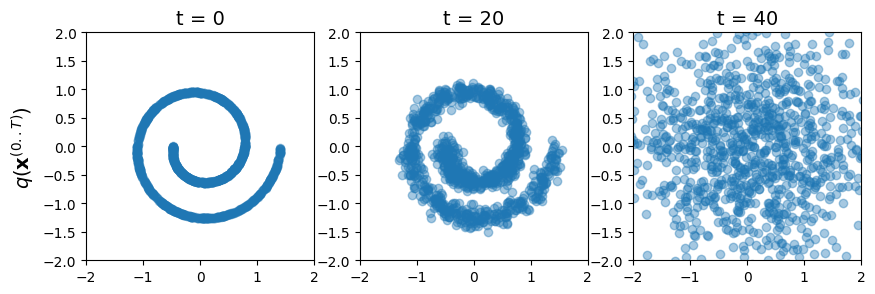

<Figure size 640x480 with 0 Axes>

In [ ]:
fig = plt.figure(figsize=(10,3))
fontsize = 14
t = [0, 20, 40]
sample = [data, model.forward_process(data, t[1]), model.forward_process(data, t[2])]
for i in range(3):
  plt.subplot(1, 3, i+1)
  plt.scatter(sample[i][:,0].data.numpy(), sample[i][:,1].data.numpy(), alpha = 0.4)
  plt.xlim([-2,2])
  plt.ylim([-2,2])
  plt.gca().set_aspect('equal')
  if i == 0:
    plt.ylabel(r'$q(\mathbf{x}^{(0..T)})$', fontsize = fontsize)
  plt.title('t = {}'.format(t[i]), fontsize = fontsize)

plt.show()
plt.savefig('forward process')

# Implement Reverse Process

In [ ]:
class DiffusionModel():

  def __init__(self, T, model: nn.Module):
    self.betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1 - 1e-5) + 1e-5
    self.alphas = 1 - self.betas
    self.alpha_bar = torch.cumprod(self.alphas, dim = 0)
    self.T = T
    self.model = model

  def sample_batch(self, batch_size, device = 'cpu'):
    data, _ = make_swiss_roll(batch_size)
    data = data[:,[2,0]]/10
    data = data * np.array([1,-1])
    return torch.from_numpy(data).to(device)

  def forward_process(self, x0, t):
    """
    :param t: Number of diffusion steps
    """
    assert t > 0 and t <= self.T, f't > 0 and t <= {self.T}'
    t = t - 1
    mu = x0 * torch.sqrt(self.alpha_bar[t])
    std = torch.sqrt(1 - self.alpha_bar[t])
    epsilon = torch.randn_like(x0)
    data = mu + std * epsilon
    return data

  def reverse_process(self, xt, t):
    """
    :param t: Number of diffusion steps
    """
    assert t > 0 and t <= self.T, f't > 0 and t <= {self.T}'

    t = t - 1

    mu, std = self.model(xt, t) # Model is made to predict the mean mu and std



